# Loss CSV Sizes Overview

Notebook for plotting multi-run validation-loss CSV files across model sizes under `outputs/loss_csv/`.


In [1]:
from pathlib import Path
import csv
import math
import matplotlib.pyplot as plt


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'analysis' / 'visualization' / 'loss_curves').is_dir() and (candidate / 'results' / 'figures').is_dir():
            return candidate
    raise RuntimeError(f'Could not locate project root from {start}')


PAPER_ROOT = find_project_root()
INPUT_DIR = PAPER_ROOT / 'analysis' / 'visualization' / 'loss_curves' / 'data'
OUTPUT_DIR = INPUT_DIR / 'plots'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

USE_LOG_Y = False
PLOT_DELTA = True
IGNORE_SMOOTH_COLUMNS = True

csv_paths = [p for p in sorted(INPUT_DIR.glob('*.csv')) if p.name != 'loss_csv_by_size_raw3_cleaned.csv']
csv_paths


[PosixPath('/Users/heshuai/Documents/99_Unsorted_Review/2026-05-15_imported_archives/02_bundle_zip/projects/Transformer-Geometry/Transformer-Geometry/Transformer-Geometry/analysis/visualization/loss_curves/data/194m.csv'),
 PosixPath('/Users/heshuai/Documents/99_Unsorted_Review/2026-05-15_imported_archives/02_bundle_zip/projects/Transformer-Geometry/Transformer-Geometry/Transformer-Geometry/analysis/visualization/loss_curves/data/1p4_baseline.csv'),
 PosixPath('/Users/heshuai/Documents/99_Unsorted_Review/2026-05-15_imported_archives/02_bundle_zip/projects/Transformer-Geometry/Transformer-Geometry/Transformer-Geometry/analysis/visualization/loss_curves/data/1p4_gate.csv'),
 PosixPath('/Users/heshuai/Documents/99_Unsorted_Review/2026-05-15_imported_archives/02_bundle_zip/projects/Transformer-Geometry/Transformer-Geometry/Transformer-Geometry/analysis/visualization/loss_curves/data/1p4_xsa.csv'),
 PosixPath('/Users/heshuai/Documents/99_Unsorted_Review/2026-05-15_imported_archives/02_bundl

In [2]:
def clean(text: str) -> str:
    return (text or '').replace('\ufeff', '').strip()

def short_run_name(col: str) -> str:
    parts = [p for p in clean(col).split('/') if p]
    if len(parts) >= 2:
        return '/'.join(parts[-2:])
    return clean(col)

def load_multirun_csv(path: Path):
    with path.open('r', encoding='utf-8', newline='') as f:
        rows = list(csv.reader(f))
    if not rows or len(rows[0]) < 2:
        raise ValueError(f'Expected at least 2 columns in {path}')

    x_name = clean(rows[0][0]) or 'step'
    all_cols = [clean(c) for c in rows[0][1:]]
    kept_indices = []
    run_names = []
    for idx, col in enumerate(all_cols):
        if IGNORE_SMOOTH_COLUMNS and '(smooth)' in col:
            continue
        kept_indices.append(idx)
        run_names.append(short_run_name(col))

    xs = []
    buckets = [[] for _ in run_names]
    for row in rows[1:]:
        if len(row) < len(all_cols) + 1:
            continue
        try:
            x = float(clean(row[0]))
        except ValueError:
            continue
        ys = []
        ok = True
        for idx in kept_indices:
            raw = row[idx + 1]
            try:
                ys.append(float(clean(raw)))
            except ValueError:
                ok = False
                break
        if not ok:
            continue
        xs.append(x)
        for bucket, y in zip(buckets, ys):
            bucket.append(y)
    return x_name, xs, list(zip(run_names, buckets))

loaded = []
for path in csv_paths:
    x_name, xs, named_series = load_multirun_csv(path)
    loaded.append((path.stem, x_name, xs, named_series))

[(size, len(xs), len(named_series)) for size, _, xs, named_series in loaded]

[('194m', 43, 3),
 ('1p4_baseline', 187, 1),
 ('1p4_gate', 50, 1),
 ('1p4_xsa', 66, 1),
 ('296m', 68, 3),
 ('436m', 65, 3),
 ('528m', 48, 3),
 ('loss_csv_by_size_raw3_cleaned', 0, 7)]

In [3]:
def plot_grid(data, delta=False, use_log_y=False, figsize=(13.5, 9.0)):
    n = len(data)
    cols = 2
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    axes_flat = axes.flatten()

    for ax in axes_flat[n:]:
        ax.axis('off')

    for ax, (size_label, x_name, xs, named_series) in zip(axes_flat, data):
        for name, ys in named_series:
            plot_ys = ys
            ylabel = 'val loss'
            if delta:
                base = ys[0]
                plot_ys = [y - base for y in ys]
                ylabel = 'val loss - first point'
            ax.plot(xs, plot_ys, linewidth=1.8, label=name)
        ax.set_title(size_label)
        ax.set_xlabel(x_name)
        ax.set_ylabel(ylabel)
        if use_log_y and not delta:
            ax.set_yscale('log')
        if delta:
            ax.axhline(0.0, color='gray', linestyle='--', linewidth=1)
        ax.grid(alpha=0.25, linestyle=':')
        ax.legend(frameon=True, fontsize=7, facecolor='white', edgecolor='#cfcfcf')

    title = 'Loss Curves by Model Size'
    if delta:
        title += ' (relative to first point)'
    fig.suptitle(title, y=0.995)
    fig.tight_layout()
    return fig


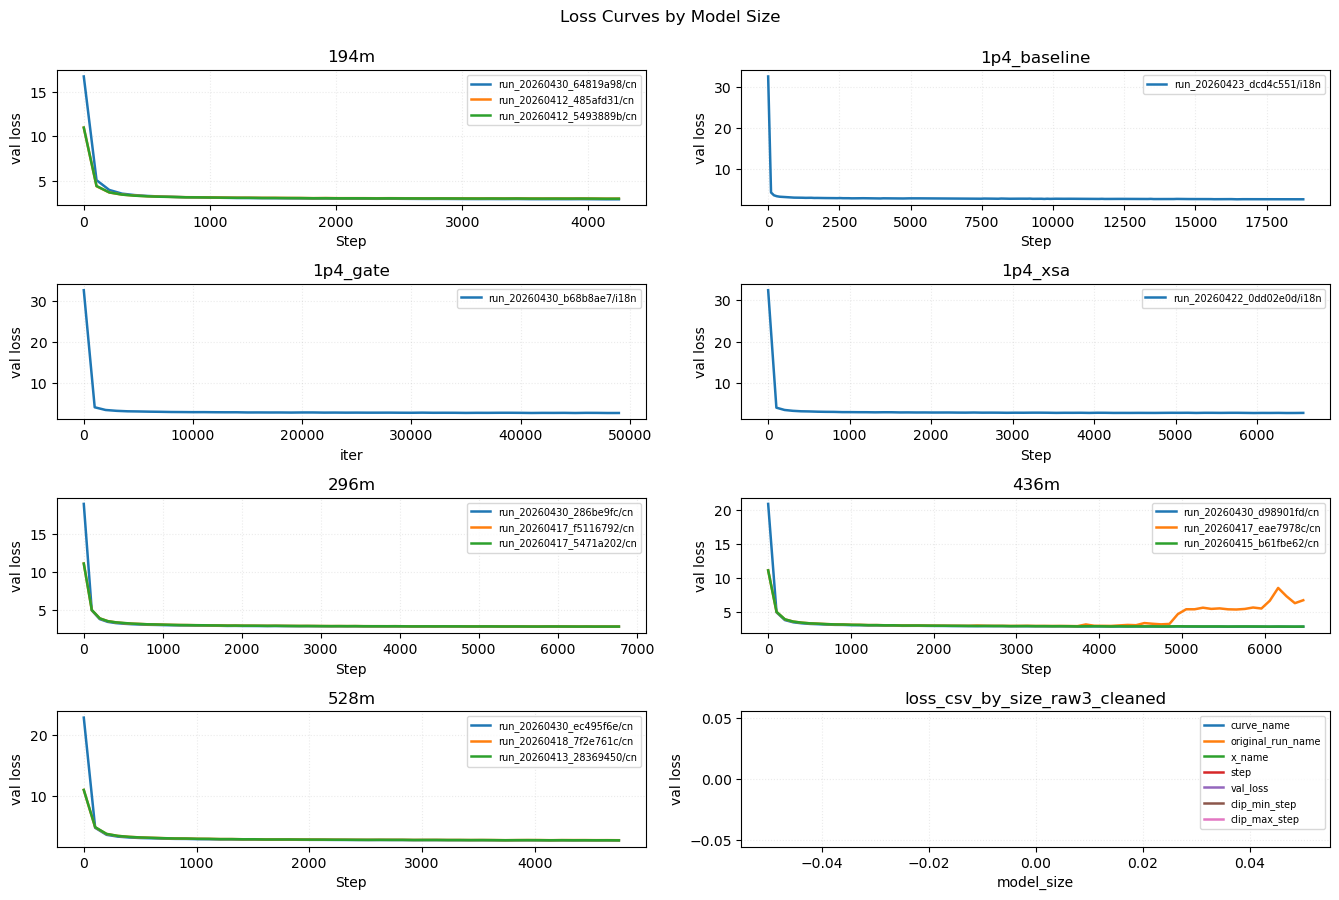

In [4]:
fig = plot_grid(loaded, delta=False, use_log_y=USE_LOG_Y)
plt.show()

IndexError: list index out of range

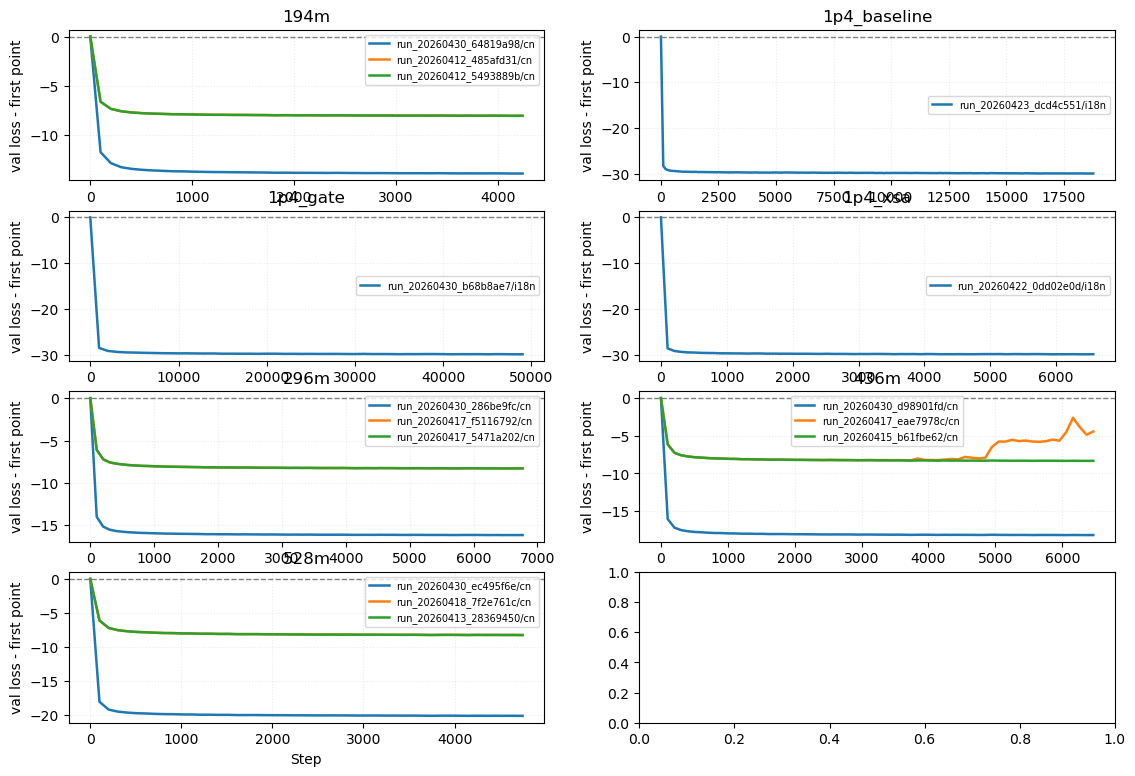

In [5]:
if PLOT_DELTA:
    fig = plot_grid(loaded, delta=True, use_log_y=USE_LOG_Y)
    plt.show()

In [ ]:
suffix = '_logy' if USE_LOG_Y else ''
abs_path = OUTPUT_DIR / f'loss_csv_sizes_overview_absolute_from_notebook{suffix}.png'
fig = plot_grid(loaded, delta=False, use_log_y=USE_LOG_Y)
fig.savefig(abs_path, dpi=220)
plt.close(fig)
print(abs_path)

if PLOT_DELTA:
    delta_path = OUTPUT_DIR / f'loss_csv_sizes_overview_delta_from_notebook{suffix}.png'
    fig = plot_grid(loaded, delta=True, use_log_y=USE_LOG_Y)
    fig.savefig(delta_path, dpi=220)
    plt.close(fig)
    print(delta_path)